# CrisisLexT6

Domain Adaptation with Adversarial Training and Graph Embeddings

---

## A. Original description


This dataset contains tweets labeled by crowdsourcing workers. Each tweet is accompanied by a label
, which is the result of the majority voting among at least 3 crowdsourcing workers.

There is one file per crisis, for each of the following disasters:

* [Sandy Hurricane 2012](https://en.wikipedia.org/wiki/Hurricane_Sandy)
* [Oklahoma Tornado Season 2013](https://en.wikipedia.org/wiki/2013_Moore_tornado)
* [West Texas Explosion 2013](https://en.wikipedia.org/wiki/West_Fertilizer_Company_explosion)
* [Alberta Floods 2013](https://en.wikipedia.org/wiki/2013_Alberta_floods)
* [Boston Bombings 2013](https://en.wikipedia.org/wiki/Boston_Marathon_bombings)
* [Queensland Floods 2013](https://en.wikipedia.org/wiki/January_2013_Eastern_Australia_floods)

On-topic/Off-topic files: `[disasters]-ontopic_offtopic.csv`

**Contents:**
Each file contains approximately 10,000 tweets. 50% of these tweets were
sampled from the geo-based sample, and 50% from the keywords-based sample.
These two samples are described in [Olteanu et al. 2014].

**Labels:**
These files contain labels indicating if a tweet is on-topic (related to
the crisis at hand), or off-topic (not related to it).

**File format:**
One tweet per line with the following comma-separated fields:
tweet id, tweet text, tweet label

### Questions/inquiries

[Olteanu et al. 2014] Alexandra Olteanu, Carlos Castillo, Fernando Diaz, Sarah Vieweg: "CrisisLex: A Lexicon for Collecting and Filtering Microblogged Communications in Crises". ICWSM 2014.

For inquiries please contact [Alexandra Olteanu](mailto:alexandra.olteanu@epfl.ch), or Carlos Castillo, or Fernando Diaz, or Sarah Vieweg.

### Version history

 * 2014-10-26: v1.0, initial release containing labeled tweets only.

## B. Overview

In [1]:
from pathlib import Path
import os
import pandas as pd

import configuration
from src import dataset_settings

from dotenv import load_dotenv
load_dotenv()

dataset_path = Path(os.getenv("DATASETS_PATH")) / 'CrisisLexT6' / 'CrisisLexT6'

Loading the `2012_Sandy_Hurricane-ontopic_offtopic.csv` file

In [2]:
filepath = dataset_path / '2012_Sandy_Hurricane' / '2012_Sandy_Hurricane-ontopic_offtopic.csv'

if not filepath.exists():
    raise FileNotFoundError(f'Not found: {filepath}')

df = pd.read_csv(filepath)
df['tweet_id'] = df['tweet id'].str.strip("'").astype('int64')
df.drop(columns=['tweet id'], inplace=True)

In [3]:
df.head()

,tweet,label,tweet_id
0,I've got enough candles to supply a Mexican fa...,off-topic,262596552399396864
1,Sandy be soooo mad that she be shattering our ...,on-topic,263044104500420609
2,@ibexgirl thankfully Hurricane Waugh played it...,off-topic,263309629973491712
3,@taos you never got that magnificent case of B...,off-topic,263422851133079552
4,"I'm at Mad River Bar &amp; Grille (New York, N...",off-topic,262404311223504896


In [4]:
csv_array = df.values

print(f'Loaded {len(df)} rows from: {filepath}')
print(csv_array[:5])

Loaded 10008 rows from: /Users/nhut/Library/CloudStorage/GoogleDrive-nduo221@aucklanduni.ac.nz/Shared drives/Nhut - Disaster on Social Media - COMPSCI 792 Research Project/Datasets/CrisisLexT6/CrisisLexT6/2012_Sandy_Hurricane/2012_Sandy_Hurricane-ontopic_offtopic.csv
[["I've got enough candles to supply a Mexican family" 'off-topic'
  262596552399396864]
 ['Sandy be soooo mad that she be shattering our doors and shiet #HurricaneSandy'
  'on-topic' 263044104500420609]
 ['@ibexgirl thankfully Hurricane Waugh played it cool and waited this one out. Ready to go at any moment tho.'
  'off-topic' 263309629973491712]
 ['@taos you never got that magnificent case of Burgundy I sent you to thank you for your tweets?'
  'off-topic' 263422851133079552]
 ["I'm at Mad River Bar &amp; Grille (New York, NY) http://t.co/VSiZrzKP"
  'off-topic' 262404311223504896]]


## C. Preprocess

Combine all train, dev, test files from both events to one

In [5]:
import json

files = [
    {
        'filename': '2012_Sandy_Hurricane/2012_Sandy_Hurricane-ontopic_offtopic.csv',
        'country': 'US',
        'event_type': 'storm',
        'year': 2012,
    },
    {
        'filename': '2013_Alberta_Floods/2013_Alberta_Floods-ontopic_offtopic.csv',
        'country': 'Canada',
        'event_type': 'flood',
        'year': 2013,
    },
    {
        'filename': '2013_Boston_Bombings/2013_Boston_Bombings-ontopic_offtopic.csv',
        'country': 'US',
        'event_type': 'bombing',
        'year': 2013,
    },
    {
        'filename': '2013_Oklahoma_Tornado/2013_Oklahoma_Tornado-ontopic_offtopic.csv',
        'country': 'US',
        'event_type': 'tornado',
        'year': 2013,
    },
    {
        'filename': '2013_Queensland_Floods/2013_Queensland_Floods-ontopic_offtopic.csv',
        'country': 'Australia',
        'event_type': 'flood',
        'year': 2013,
    },
    {
        'filename': '2013_West_Texas_Explosion/2013_West_Texas_Explosion-ontopic_offtopic.csv',
        'country': 'US',
        'event_type': 'explosion',
        'year': 2013,
    }
]

df_list = []

for file in files:
    filename = file['filename']
    filepath = dataset_path / filename
    if not filepath.exists():
        print(f'Not found: {filepath}')
        continue

    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip()
    
    df['tweet_id'] = df['tweet id'].str.strip("'").astype('int64')
    df.drop(columns=['tweet id'], inplace=True)
    df['event_type'] = file['event_type']
    df['country'] = file['country']
    df['year'] = file['year']
    df['relevant'] = df['label'].apply(lambda x: False if x == "off-topic" else True)
    df['dataset'] = 'CrisisLexT6'
    df.rename(columns={'label': 'original_label'}, inplace=True)
    df["meta"] = df.apply(
        lambda row: {
            'file_name': filename,
        },
        axis=1,
    )
    df_list.append(df)

# ignore_index=True creates clean, sequential row numbers
merged_df = pd.concat(df_list, ignore_index=True)

merged_df.rename(columns={'tweet': 'tweet_text'}, inplace=True)
merged_df = merged_df[dataset_settings.dataset_extended_cols]

merged_df.head()

,tweet_id,tweet_text,relevant,event_type,dataset,original_label,country,year,meta
0,262596552399396864,I've got enough candles to supply a Mexican fa...,False,storm,CrisisLexT6,off-topic,US,2012,{'file_name': '2012_Sandy_Hurricane/2012_Sandy...
1,263044104500420609,Sandy be soooo mad that she be shattering our ...,True,storm,CrisisLexT6,on-topic,US,2012,{'file_name': '2012_Sandy_Hurricane/2012_Sandy...
2,263309629973491712,@ibexgirl thankfully Hurricane Waugh played it...,False,storm,CrisisLexT6,off-topic,US,2012,{'file_name': '2012_Sandy_Hurricane/2012_Sandy...
3,263422851133079552,@taos you never got that magnificent case of B...,False,storm,CrisisLexT6,off-topic,US,2012,{'file_name': '2012_Sandy_Hurricane/2012_Sandy...
4,262404311223504896,"I'm at Mad River Bar &amp; Grille (New York, N...",False,storm,CrisisLexT6,off-topic,US,2012,{'file_name': '2012_Sandy_Hurricane/2012_Sandy...


In [6]:
# TODO: Clean for duplicates in the 'tweet_text' column.
print(f"Number of duplicate tweets: {merged_df['tweet_text'].duplicated().sum()}")

# # Remove duplicates
merged_df = merged_df.drop_duplicates(subset=['tweet_text'])

merged_df['tweet_text'].value_counts()

Number of duplicate tweets: 4705


tweet_text
I've got enough candles to supply a Mexican family                                                                                              1
RT @BreakingNewzman: Oklahoma Medical Examiner has ID 23 of 24 confirmed dead from tornado, incl 10 kids RT@AP http://t.co/9aUE2V9SPY  http…    1
An assortment of ways YOU can help Oklahoma horsepeople, from writing checks to sending supplies. http://t.co/suZKXeQy6U                        1
Obama visits Oklahoma to comfort tornado victims, thank rescuers - Fox News  http://t.co/tFCrO03XxM                                             1
“@billboard: Blake Shelton is organizing an NBC benefit concert for #Oklahoma tornado victims http://t.co/8GlZpPxAGs” you're so perfect         1
                                                                                                                                               ..
RT @lonnietaylor: Downtown smells like a wet dog. Not the worst thing I've smelled down here, but noticeable. #yy

In [7]:
import csv
# Use QUOTE_ALL to quote all fields, ensuring newlines and special characters are properly handled
merged_df.to_csv('datasets/CrisisLexT6.csv', index=False, quoting=csv.QUOTE_ALL)

#### Verifing

In [8]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55377 entries, 0 to 60081
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   tweet_id        55377 non-null  int64 
 1   tweet_text      55377 non-null  object
 2   relevant        55377 non-null  bool  
 3   event_type      55377 non-null  object
 4   dataset         55377 non-null  object
 5   original_label  55377 non-null  object
 6   country         55377 non-null  object
 7   year            55377 non-null  int64 
 8   meta            55377 non-null  object
dtypes: bool(1), int64(2), object(6)
memory usage: 3.9+ MB


In [9]:
merged_df.describe(include='all')

,tweet_id,tweet_text,relevant,event_type,dataset,original_label,country,year,meta
count,5.537700e+04,55377,55377,55377,55377,55377,55377,55377.000000,55377
unique,NaN,55377,2,5,1,2,3,NaN,6
top,NaN,I've got enough candles to supply a Mexican fa...,True,flood,CrisisLexT6,on-topic,US,NaN,{'file_name': '2012_Sandy_Hurricane/2012_Sandy...
freq,NaN,1,27884,18436,55377,27884,36941,NaN,9431
mean,3.160559e+17,NaN,NaN,NaN,NaN,NaN,NaN,2012.829695,NaN
std,2.901164e+16,NaN,NaN,NaN,NaN,NaN,NaN,0.375904,NaN
min,2.623429e+17,NaN,NaN,NaN,NaN,NaN,NaN,2012.000000,NaN
25%,2.961000e+17,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN
50%,3.249059e+17,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN
75%,3.372908e+17,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN


<Axes: xlabel='event_type'>

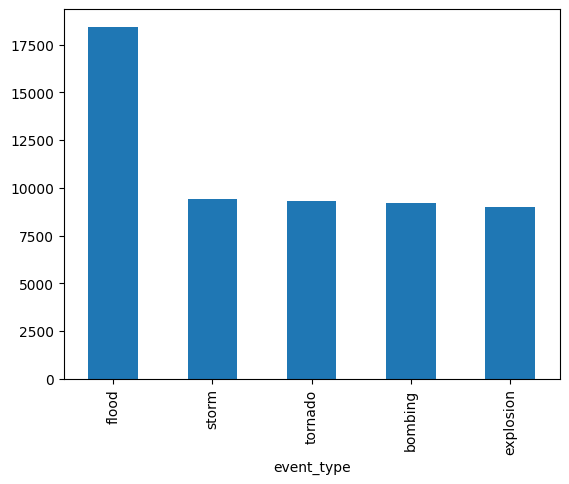

In [10]:
merged_df['event_type'].value_counts().plot(kind='bar')

<Axes: xlabel='relevant'>

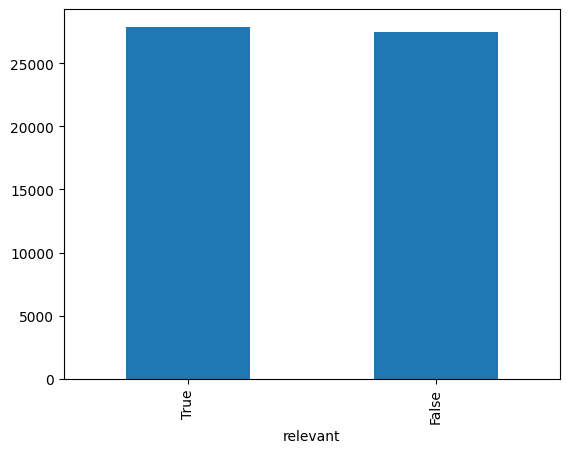

In [11]:
merged_df['relevant'].value_counts().plot(kind='bar')